Setup & Load MNIST Dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import fetch_openml
import wandb

# Inisialisasi W&B
run = wandb.init(project="mnist-neural-networks", name="mlp-baseline")

# Load MNIST Dataset (Angka 0-9)
print("Loading MNIST data... (Mohon tunggu)")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')

# Normalisasi: Mengubah rentang pixel 0-255 menjadi 0-1 agar NN belajar lebih cepat
X = X / 255.0

print(f"Data Loaded. Shape: {X.shape}")

Loading MNIST data... (Mohon tunggu)
Data Loaded. Shape: (70000, 784)


Visualisasi Data Tulisan Tangan

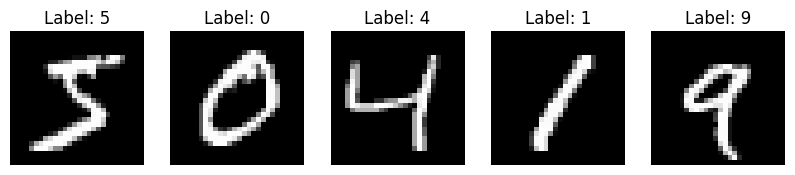

In [9]:
# Mari kita lihat apa yang dilihat oleh AI
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()

# Log contoh gambar ke W&B
wandb.log({"mnist_examples": [wandb.Image(X[i].reshape(28, 28), caption=f"Label: {y[i]}") for i in range(5)]})

Pelatihan Multi-Layer Perceptron

In [10]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membangun Arsitektur Jaringan Saraf
# hidden_layer_sizes=(128, 64) artinya ada 2 hidden layer dengan 128 dan 64 neuron
mlp = MLPClassifier(hidden_layer_sizes=(128, 64),
                    activation='relu',
                    solver='adam',
                    learning_rate_init=0.001, # Kecepatan belajar awal
                    alpha=0.0001, # Tambahkan ini: L2 Penalty (Regularisasi)
                    max_iter=20, # Kita batasi iterasi agar cepat untuk latihan
                    verbose=True,
                    random_state=42)

print("Melatih Jaringan Saraf...")
mlp.fit(X_train, y_train)

Melatih Jaringan Saraf...
Iteration 1, loss = 0.39286260
Iteration 2, loss = 0.15239755
Iteration 3, loss = 0.10608706
Iteration 4, loss = 0.08038778
Iteration 5, loss = 0.06403363
Iteration 6, loss = 0.05088564
Iteration 7, loss = 0.04088828
Iteration 8, loss = 0.03441392
Iteration 9, loss = 0.02911492
Iteration 10, loss = 0.02490929
Iteration 11, loss = 0.01988026
Iteration 12, loss = 0.01600589
Iteration 13, loss = 0.01437448
Iteration 14, loss = 0.01047791
Iteration 15, loss = 0.01086533
Iteration 16, loss = 0.00985182
Iteration 17, loss = 0.00891190
Iteration 18, loss = 0.00688038
Iteration 19, loss = 0.00833706
Iteration 20, loss = 0.00814995


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20, random_state=42,
              verbose=True)

Multi eksperimen

In [7]:
from sklearn.metrics import accuracy_score
import pandas as pd

experiments = [
    {
        "name": "baseline_relu_adam",
        "hidden_layer_sizes": (128, 64),
        "activation": "relu",
        "solver": "adam",
        "learning_rate_init": 0.001,
        "alpha": 0.0001
    },
    {
        "name": "small_1layer_10_relu",
        "hidden_layer_sizes": (10,),
        "activation": "relu",
        "solver": "adam",
        "learning_rate_init": 0.001,
        "alpha": 0.0001
    },
    {
        "name": "big_3layer_relu",
        "hidden_layer_sizes": (256, 128, 64),
        "activation": "relu",
        "solver": "adam",
        "learning_rate_init": 0.001,
        "alpha": 0.0001
    },
    {
        "name": "big_3layer_tanh",
        "hidden_layer_sizes": (256, 128, 64),
        "activation": "tanh",
        "solver": "adam",
        "learning_rate_init": 0.001,
        "alpha": 0.0001
    },
    {
        "name": "big_3layer_logistic",
        "hidden_layer_sizes": (256, 128, 64),
        "activation": "logistic",
        "solver": "adam",
        "learning_rate_init": 0.001,
        "alpha": 0.0001
    },
    {
        "name": "lr_too_big",
        "hidden_layer_sizes": (128, 64),
        "activation": "relu",
        "solver": "adam",
        "learning_rate_init": 0.5,
        "alpha": 0.0001
    },
    {
        "name": "lr_too_small",
        "hidden_layer_sizes": (128, 64),
        "activation": "relu",
        "solver": "adam",
        "learning_rate_init": 0.000001,
        "alpha": 0.0001
    },
    {
        "name": "alpha_big",
        "hidden_layer_sizes": (128, 64),
        "activation": "relu",
        "solver": "adam",
        "learning_rate_init": 0.001,
        "alpha": 1.0
    },
    {
        "name": "solver_sgd",
        "hidden_layer_sizes": (128, 64),
        "activation": "relu",
        "solver": "sgd",
        "learning_rate_init": 0.001,
        "alpha": 0.0001
    },
    {
        "name": "exp9_1layer_32_relu",
        "hidden_layer_sizes": (32,),
        "activation": "relu",
        "solver": "adam",
        "learning_rate_init": 0.001,
        "alpha": 0.0001
    },
    {
        "name": "exp10_3layer_relu_alpha001",
        "hidden_layer_sizes": (256, 128, 64),
        "activation": "relu",
        "solver": "adam",
        "learning_rate_init": 0.001,
        "alpha": 0.01
    }
]

results = []

for exp in experiments:
    print(f"\n=== Menjalankan eksperimen: {exp['name']} ===")

    run = wandb.init(
        project="mnist-neural-networks",
        name=exp["name"],
        reinit=True
    )

    mlp = MLPClassifier(
        hidden_layer_sizes=exp["hidden_layer_sizes"],
        activation=exp["activation"],
        solver=exp["solver"],
        learning_rate_init=exp["learning_rate_init"],
        alpha=exp["alpha"],
        max_iter=20,
        verbose=True,
        random_state=42
    )

    mlp.fit(X_train, y_train)

    y_train_pred = mlp.predict(X_train)
    y_test_pred = mlp.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    for i, loss in enumerate(mlp.loss_curve_):
        wandb.log({"loss": loss, "epoch": i})

    wandb.log({
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "hidden_layer_sizes": str(exp["hidden_layer_sizes"]),
        "activation": exp["activation"],
        "solver": exp["solver"],
        "learning_rate_init": exp["learning_rate_init"],
        "alpha": exp["alpha"]
    })

    results.append({
        "name": exp["name"],
        "hidden_layer_sizes": exp["hidden_layer_sizes"],
        "activation": exp["activation"],
        "solver": exp["solver"],
        "learning_rate_init": exp["learning_rate_init"],
        "alpha": exp["alpha"],
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "final_loss": mlp.loss_curve_[-1]
    })

    wandb.finish()

results_df = pd.DataFrame(results)
results_df


=== Menjalankan eksperimen: baseline_relu_adam ===


Iteration 1, loss = 0.39286260
Iteration 2, loss = 0.15239755
Iteration 3, loss = 0.10608706
Iteration 4, loss = 0.08038778
Iteration 5, loss = 0.06403363
Iteration 6, loss = 0.05088564
Iteration 7, loss = 0.04088828
Iteration 8, loss = 0.03441392
Iteration 9, loss = 0.02911492
Iteration 10, loss = 0.02490929
Iteration 11, loss = 0.01988026
Iteration 12, loss = 0.01600589
Iteration 13, loss = 0.01437448
Iteration 14, loss = 0.01047791
Iteration 15, loss = 0.01086533
Iteration 16, loss = 0.00985182
Iteration 17, loss = 0.00891190
Iteration 18, loss = 0.00688038
Iteration 19, loss = 0.00833706
Iteration 20, loss = 0.00814995


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


alpha,▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
learning_rate_init,▁
loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
test_accuracy,▁
train_accuracy,▁
activation,relu
alpha,0.0001
epoch,19
hidden_layer_sizes,"(128, 64)"
learning_rate_init,0.001



=== Menjalankan eksperimen: small_1layer_10_relu ===


...


=== Menjalankan eksperimen: exp10_3layer_relu_alpha001 ===


Iteration 1, loss = 0.33727417
Iteration 2, loss = 0.13346966
Iteration 3, loss = 0.09451436
Iteration 4, loss = 0.07239226
Iteration 5, loss = 0.06163500
Iteration 6, loss = 0.05276295
Iteration 7, loss = 0.04636095
Iteration 8, loss = 0.04353331
Iteration 9, loss = 0.03839740
Iteration 10, loss = 0.03652841
Iteration 11, loss = 0.03665577
Iteration 12, loss = 0.03496452
Iteration 13, loss = 0.03480952
Iteration 14, loss = 0.03368110
Iteration 15, loss = 0.03032068
Iteration 16, loss = 0.03356167
Iteration 17, loss = 0.03658095
Iteration 18, loss = 0.02890898
Iteration 19, loss = 0.03122233
Iteration 20, loss = 0.03171575


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


alpha,▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
learning_rate_init,▁
loss,█▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_accuracy,▁
train_accuracy,▁
activation,relu
alpha,0.01
epoch,19
hidden_layer_sizes,"(256, 128, 64)"
learning_rate_init,0.001


,name,hidden_layer_sizes,activation,solver,learning_rate_init,alpha,train_accuracy,test_accuracy,final_loss
0,baseline_relu_adam,"(128, 64)",relu,adam,0.001000,0.0001,0.995589,0.972429,0.008150
1,small_1layer_10_relu,"(10,)",relu,adam,0.001000,0.0001,0.945536,0.934429,0.197625
2,big_3layer_relu,"(256, 128, 64)",relu,adam,0.001000,0.0001,0.998429,0.977857,0.007008
3,big_3layer_tanh,"(256, 128, 64)",tanh,adam,0.001000,0.0001,0.999411,0.977571,0.007815
4,big_3layer_logistic,"(256, 128, 64)",logistic,adam,0.001000,0.0001,0.999304,0.976000,0.010701
5,lr_too_big,"(128, 64)",relu,adam,0.500000,0.0001,0.098732,0.092500,2.345582
6,lr_too_small,"(128, 64)",relu,adam,0.000001,0.0001,0.561214,0.566571,1.838373
7,alpha_big,"(128, 64)",relu,adam,0.001000,1.0000,0.970464,0.962857,0.340520
8,solver_sgd,"(128, 64)",relu,sgd,0.001000,0.0001,0.940089,0.935643,0.216664
9,exp9_1layer_32_relu,"(32,)",relu,adam,0.001000,0.0001,0.981732,0.963571,0.069509


Evaluasi & Tracking W&B

In [11]:
# Ambil eksperimen terbaik berdasarkan test accuracy
best_row = results_df.loc[results_df["test_accuracy"].idxmax()]
print("Eksperimen terbaik:")
print(best_row)

# Latih ulang model terbaik supaya bisa dipakai evaluasi final
best_mlp = MLPClassifier(
    hidden_layer_sizes=best_row["hidden_layer_sizes"],
    activation=best_row["activation"],
    solver=best_row["solver"],
    learning_rate_init=best_row["learning_rate_init"],
    alpha=best_row["alpha"],
    max_iter=20,
    verbose=True,
    random_state=42
)

best_mlp.fit(X_train, y_train)

y_pred = best_mlp.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nAkurasi MLP terbaik: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Eksperimen terbaik:
name                  big_3layer_relu
hidden_layer_sizes     (256, 128, 64)
activation                       relu
solver                           adam
learning_rate_init              0.001
alpha                          0.0001
train_accuracy               0.998429
test_accuracy                0.977857
final_loss                   0.007008
Name: 2, dtype: object
Iteration 1, loss = 0.32158290
Iteration 2, loss = 0.11784227
Iteration 3, loss = 0.07776151
Iteration 4, loss = 0.05371267
Iteration 5, loss = 0.04143093
Iteration 6, loss = 0.03283858
Iteration 7, loss = 0.02682117
Iteration 8, loss = 0.01974053
Iteration 9, loss = 0.01751836
Iteration 10, loss = 0.01222624
Iteration 11, loss = 0.01280319
Iteration 12, loss = 0.01560845
Iteration 13, loss = 0.01005697
Iteration 14, loss = 0.01162889
Iteration 15, loss = 0.00869685
Iteration 16, loss = 0.01296234
Iteration 17, loss = 0.01207279
Iteration 18, loss = 0.00503507
Iteration 19, loss = 0.01035662
Iteration 20, lo

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(



Akurasi MLP terbaik: 0.9779

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.97      0.98      0.97      1380
           3       0.99      0.97      0.98      1433
           4       0.98      0.97      0.97      1295
           5       0.98      0.98      0.98      1273
           6       0.98      0.99      0.98      1396
           7       0.99      0.97      0.98      1503
           8       0.97      0.96      0.97      1357
           9       0.95      0.98      0.96      1420

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



Analisis Kesalahan (Confusion Matrix)

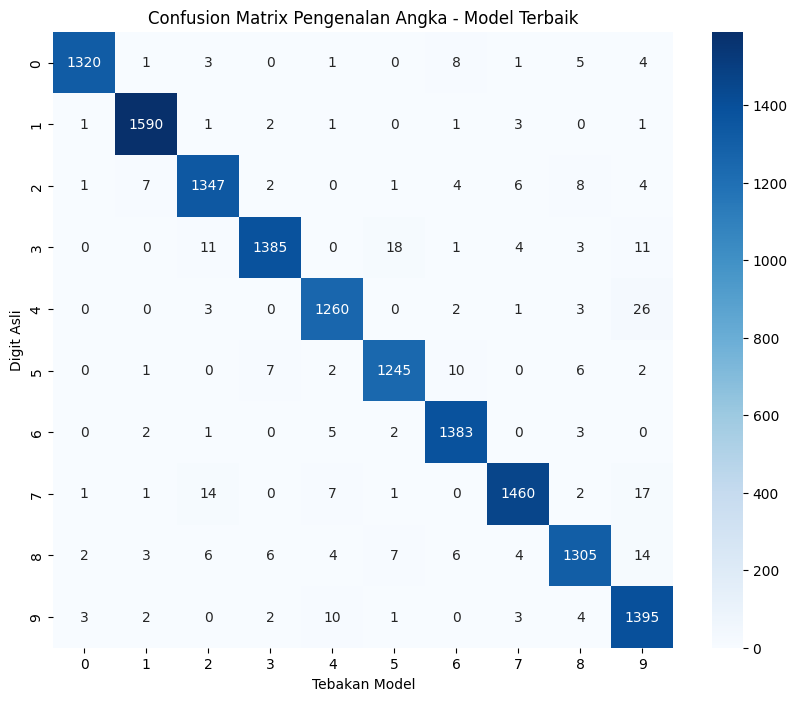

In [12]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tebakan Model')
plt.ylabel('Digit Asli')
plt.title('Confusion Matrix Pengenalan Angka - Model Terbaik')
plt.show()